# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import re
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [36]:
corpus = """
machine learning helps computers learn patterns from data
deep learning is a subset of machine learning
neural networks are inspired by the human brain
data science combines statistics programming and domain knowledge
artificial intelligence enables machines to perform intelligent tasks
natural language processing helps computers understand human language
recurrent neural networks are useful for sequence modeling
lstm networks capture long term dependencies in text
gru networks provide efficient sequence learning mechanisms
"""
print(corpus)


machine learning helps computers learn patterns from data
deep learning is a subset of machine learning
neural networks are inspired by the human brain
data science combines statistics programming and domain knowledge
artificial intelligence enables machines to perform intelligent tasks
natural language processing helps computers understand human language
recurrent neural networks are useful for sequence modeling
lstm networks capture long term dependencies in text
gru networks provide efficient sequence learning mechanisms



In [37]:
corpus = corpus.lower()
corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [38]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 57
X shape: (62, 7)
y shape: (62,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [39]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
SimpleRNN(128, dropout=0.2),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [40]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128, dropout=0.2),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [46]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
   GRU(128, dropout=0.2),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

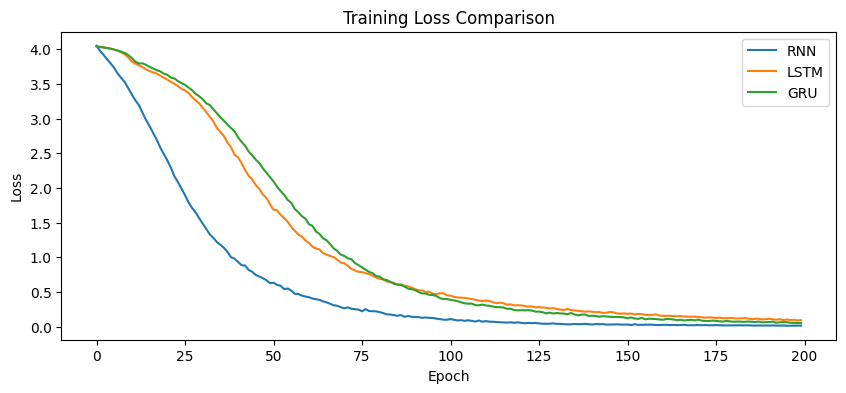

In [42]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [47]:
print("Final Training Loss")
print("RNN  :", round(rnn_history.history['loss'][-1],4))
print("LSTM :", round(lstm_history.history['loss'][-1],4))
print("GRU  :", round(gru_history.history['loss'][-1],4))

Final Training Loss
RNN  : 0.0153
LSTM : 0.0938
GRU  : 0.0267


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [43]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [44]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a subset of machine learning helps computers learn patterns
LSTM: deep learning is a subset of machine learning learning of patterns from
GRU : deep learning is a subset of machine learning is a subset of


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

In [48]:
print("""
Conclusion:
1. Vanilla RNN achieved the lowest training loss on the given corpus.
2. GRU also performed well and generated coherent text sequences.
3. LSTM successfully captured contextual dependencies but resulted in higher training loss.
4. All three models were capable of learning the corpus structure and generating meaningful text.
""")


Conclusion:
1. Vanilla RNN achieved the lowest training loss on the given corpus.
2. GRU also performed well and generated coherent text sequences.
3. LSTM successfully captured contextual dependencies but resulted in higher training loss.
4. All three models were capable of learning the corpus structure and generating meaningful text.

